# Libraries

In [1]:
from tqdm import tqdm
import jiwer
import os
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

In [2]:
txt_dir = "../data/converted/thai-central-to-vctk/txt"
wav_dir = "../data/converted/thai-central-to-vctk/wav16_silence_trimmed"

# Create Pipeline and Dataset

In [3]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "scb10x/monsoon-whisper-medium-gigaspeech2"

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
)
model.to(device)

processor = AutoProcessor.from_pretrained(model_id)

pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    torch_dtype=torch_dtype,
    device=device,
)


Device set to use cuda:0


In [4]:
class CustomDataset:
    def __init__(self, txt_dir, wav_dir):
        self.txt_dir = txt_dir
        self.wav_dir = wav_dir
        self.txts = []
        self.wav_files = []
        for speaker in tqdm(os.listdir(txt_dir)):
            for filename in os.listdir(os.path.join(txt_dir, speaker)):
                filename = filename.split(".")[0]
                txt_file = os.path.join(txt_dir, speaker, filename + ".txt")
                wav_file = os.path.join(wav_dir, speaker, filename + ".flac")
                if os.path.exists(txt_file) and os.path.exists(wav_file):
                    with open(txt_file, "r") as f:
                        txt = f.read()
                    self.txts.append(txt)
                    self.wav_files.append(wav_file)

    def __len__(self):
        return len(self.txts)

    def __getitem__(self, idx):
        return self.txts[idx], self.wav_files[idx]

In [5]:
dataset = CustomDataset(txt_dir, wav_dir)

100%|██████████| 984/984 [00:06<00:00, 151.67it/s]


In [6]:
print(dataset[0])

('ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอกฟาร์มขวดละหนึ่งแสนหนึ่งหมื่นบาทค่ะ', '../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0864/thai-central_201353_mic1.flac')


In [7]:
preset_batch_size = 32
dataloader = torch.utils.data.DataLoader(dataset, batch_size=preset_batch_size, shuffle=False)

In [8]:
for batch in dataloader:
    print(batch)
    break

[('ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอกฟาร์มขวดละหนึ่งแสนหนึ่งหมื่นบาทค่ะ', 'นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิทธิชุมชนกล่าวว่าปัจจุบันมีสิ่งปลูกสร้างบริเวณเชิงดอยสุเทพเป็นจำนวนมากไม่เว้นแม้แต่คณะเกษตรศาสตร์', 'ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย่างมานี้ไม่ใช่ประสบการณ์ตรงของผมนะครับผมเที่ยวเก็บจากโน่นจากนี่เท่านั้นเพราะตั้งแต่เกิดมายังไม่เคยเจอะเจอผู้ดีเก่าฝรั่งสักคน', 'ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ', 'กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง', 'แล้วพวกเราล่ะไม่ชวนบ้างหรือเจาะจงชวนแต่คุณนุชนะป๊ะดอกเตอร์ร์ร์', 'ดังนั้นทางออกเดียวของเขาในตอนนี้คือต้องรีบหนีเข้าไปภายในเมืองครีกทาวน์', 'นอกจากเขื่อนป่าสักชลสิทธิ์จะทำการกักเก็บน้ำแล้วยังเป็นสถานที่ท่องเที่ยวสำคัญของจังหวัดลพบุรีซึ่งทางด้านสถานที่ท่องเที่ยวในบริเวณเขื่อนป่าสักชลสิทธิ์มีหลากหลาย', 'ใครว่าล่ะแล้วลือตอนไหนทำไมเงียบจัง', 'จอร์จิน่าก็คือหนิงเจียว', 'ก็ออกมาแต่งวางตามตู้กระจกทั้งตู้กลางห้องตู้ติดผนังและตู้โชว์หน้าร้านอันเป็นกิจวัตรประจำทุกค่ำเช้าที่ทั้งนายจ้างและหล่อนจะต้องทำเมื่อมาถึงและเมื่อ

# Transcribing as Batches

In [9]:
import warnings
warnings.filterwarnings("ignore")


In [10]:
out_dir = './transcribed_monsoon.txt'
batch_counter = 0
txts = []
transcripts = []
filenames = []

for batch in tqdm(dataloader, desc="Transcribing"):
    batch_size = len(batch[1])  # Get the actual batch size
    try:
        transcribed = pipe(list(batch[1]), batch_size=batch_size, generate_kwargs={"language": "thai"})  # Assuming batch[1] contains audio data
        transcripts.extend(["".join(t['text'].split()) for t in transcribed])
    except Exception as e:
        print(f"Error in batch {batch_counter}: {e}")
        transcripts.extend([-1] * batch_size)  # Fallback for errors
    
    filenames.extend(batch[1])
    txts.extend(["".join(t.split()) for t in list(batch[0])])  # Assuming batch[0] contains reference texts

    # Write to file every 20 batches
    if batch_counter % 20 == 0 and batch_counter > 0:
        with open(out_dir, "a") as f:
            for filename, txt, transcript in zip(filenames, txts, transcripts):
                f.write(f"{filename}|{txt}|{transcript}\n")
        
        txts.clear()
        transcripts.clear()
        filenames.clear()

    batch_counter += 1

# Write any remaining data after the loop
if txts:
    with open(out_dir, "a") as f:
        for filename, txt, transcript in zip(filenames, txts, transcripts):
            f.write(f"{filename}|{txt}|{transcript}\n")


Transcribing:   0%|          | 15/7033 [01:19<8:47:06,  4.51s/it] 

Error in batch 14: The elements of the batch contain different keys. Cannot batch them ({'is_last', 'input_features', 'attention_mask'} != {'is_last', 'input_features', 'attention_mask', 'num_frames'})


Transcribing:   1%|          | 86/7033 [07:43<8:34:27,  4.44s/it] 

Error in batch 85: The elements of the batch contain different keys. Cannot batch them ({'is_last', 'input_features', 'attention_mask'} != {'is_last', 'input_features', 'attention_mask', 'num_frames'})


Transcribing:   5%|▌         | 379/7033 [33:54<8:06:09,  4.38s/it] 

...

Transcribing:  97%|█████████▋| 6835/7033 [10:00:00<11:18,  3.43s/it]

Error in batch 6834: The elements of the batch contain different keys. Cannot batch them ({'is_last', 'input_features', 'attention_mask'} != {'is_last', 'input_features', 'attention_mask', 'num_frames'})


Transcribing:  97%|█████████▋| 6854/7033 [10:01:23<12:25,  4.16s/it]

Error in batch 6853: The elements of the batch contain different keys. Cannot batch them ({'is_last', 'input_features', 'attention_mask'} != {'is_last', 'input_features', 'attention_mask', 'num_frames'})


Transcribing: 100%|██████████| 7033/7033 [10:16:10<00:00,  5.26s/it]


In [11]:
import pandas as pd

df = pd.read_csv('transcribed_monsoon.txt', sep='|', header=None)
df.columns = ['filename', 'txt', 'transcript']
df

,filename,txt,transcript
0,../data/converted/thai-central-to-vctk/wav16_s...,ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอ...,น้ําบันเบอรี่๑๐๐วังภูหมอกความขวดละ๑๑๐๐๐บาทค่ะ
1,../data/converted/thai-central-to-vctk/wav16_s...,นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิ...,นายชัยพันธ์ประพาสวัสดิ์ผู้อํานวยการสถาบันเพื่อ...
2,../data/converted/thai-central-to-vctk/wav16_s...,ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...,ดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย่างมาน...
3,../data/converted/thai-central-to-vctk/wav16_s...,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ
4,../data/converted/thai-central-to-vctk/wav16_s...,กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง,กรรมการได้ทําการปรึกษากันชั่วขณะหนึ่ง
...,...,...,...
225023,../data/converted/thai-central-to-vctk/wav16_s...,เห็ดเผาะหรือเห็ดถอบ,หรือเห็ดถอบ
225024,../data/converted/thai-central-to-vctk/wav16_s...,บ้าแล้วเวนคืนได้ด้วยเหรออืมดีจัง,บ้าแล้วเวรคืนได้ด้วยเหรออืมดีจัง
225025,../data/converted/thai-central-to-vctk/wav16_s...,หิวยังหืมเจ้าตัวเล็ก,หิวยังเจ้าตัวเล็ก
225026,../data/converted/thai-central-to-vctk/wav16_s...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...,สังเกตที่สําคัญของปัญหาคือปริมาณน้ําที่เข้าปลา...


In [12]:
print(f"Number of -1 in transcripts: {df[df['transcript'] == '-1'].shape[0]} from {df.shape[0]} total rows")
print(f"Which is {df[df['transcript'] == '-1'].shape[0] / df.shape[0] * 100:.2f}% of the data")

Number of -1 in transcripts: 3520 from 225028 total rows
Which is 1.56% of the data


# Transcribing the Failed Ones

In [13]:
out_dir = 'transcribed_monsoon_refined.csv'
for row in tqdm(df.iterrows(), total=len(df)):
    i = row[0]
    row = row[1]
    if row['transcript'] != '-1':
        continue
    try:
        assert row['txt'] == dataset[i][0]
        transcribed = pipe([dataset[i][1]], batch_size=1, generate_kwargs={"language": "thai"})
        transcript = "".join(transcribed[0]['text'].split())
        df.at[i, 'transcript'] = transcript
    except Exception as e:
        print(f"Error transcribing {row['filename']}: {e}")
        continue
df.to_csv(out_dir, index=False, sep='|', header=False)

  0%|          | 469/225028 [00:15<2:51:25, 21.83it/s]

Error transcribing ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0744/thai-central_290817_mic1.flac: You have passed more than 3000 mel input features (> 30 seconds) which automatically enables long-form generation which requires the model to predict timestamp tokens. Please either pass `return_timestamps=True` or make sure to pass no more than 3000 mel input features.


  1%|          | 2721/225028 [00:27<22:37, 163.79it/s]

Error transcribing ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0257/thai-central_176424_mic1.flac: You have passed more than 3000 mel input features (> 30 seconds) which automatically enables long-form generation which requires the model to predict timestamp tokens. Please either pass `return_timestamps=True` or make sure to pass no more than 3000 mel input features.


  5%|▌         | 12112/225028 [01:16<13:37, 260.46it/s]

...

 97%|█████████▋| 218700/225028 [47:37<03:53, 27.13it/s] 

Error transcribing ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0176/thai-central_182206_mic1.flac: You have passed more than 3000 mel input features (> 30 seconds) which automatically enables long-form generation which requires the model to predict timestamp tokens. Please either pass `return_timestamps=True` or make sure to pass no more than 3000 mel input features.


 97%|█████████▋| 219297/225028 [47:57<01:55, 49.64it/s]

Error transcribing ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0489/thai-central_105368_mic1.flac: You have passed more than 3000 mel input features (> 30 seconds) which automatically enables long-form generation which requires the model to predict timestamp tokens. Please either pass `return_timestamps=True` or make sure to pass no more than 3000 mel input features.


100%|██████████| 225028/225028 [48:23<00:00, 77.51it/s] 


In [14]:
print(f"Number of -1 in transcripts: {df[df['transcript'] == '-1'].shape[0]} from {df.shape[0]} total rows")
print(f"Which is {df[df['transcript'] == '-1'].shape[0] / df.shape[0] * 100:.2f}% of the data")

Number of -1 in transcripts: 116 from 225028 total rows
Which is 0.05% of the data


# CER Analysis

In [15]:
cers = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    txt = row['txt']
    transcript = row['transcript']
    cer = jiwer.cer(txt, transcript)
    cers.append(cer)
    df.at[i, 'cer'] = cer

df

100%|██████████| 225028/225028 [00:22<00:00, 10029.09it/s]


,filename,txt,transcript,cer
0,../data/converted/thai-central-to-vctk/wav16_s...,ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอ...,น้ําบันเบอรี่๑๐๐วังภูหมอกความขวดละ๑๑๐๐๐บาทค่ะ,0.641975
1,../data/converted/thai-central-to-vctk/wav16_s...,นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิ...,นายชัยพันธ์ประพาสวัสดิ์ผู้อํานวยการสถาบันเพื่อ...,0.084507
2,../data/converted/thai-central-to-vctk/wav16_s...,ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...,ดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย่างมาน...,0.082353
3,../data/converted/thai-central-to-vctk/wav16_s...,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,0.000000
4,../data/converted/thai-central-to-vctk/wav16_s...,กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง,กรรมการได้ทําการปรึกษากันชั่วขณะหนึ่ง,0.055556
...,...,...,...,...
225023,../data/converted/thai-central-to-vctk/wav16_s...,เห็ดเผาะหรือเห็ดถอบ,หรือเห็ดถอบ,0.421053
225024,../data/converted/thai-central-to-vctk/wav16_s...,บ้าแล้วเวนคืนได้ด้วยเหรออืมดีจัง,บ้าแล้วเวรคืนได้ด้วยเหรออืมดีจัง,0.031250
225025,../data/converted/thai-central-to-vctk/wav16_s...,หิวยังหืมเจ้าตัวเล็ก,หิวยังเจ้าตัวเล็ก,0.150000
225026,../data/converted/thai-central-to-vctk/wav16_s...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...,สังเกตที่สําคัญของปัญหาคือปริมาณน้ําที่เข้าปลา...,0.075000


In [16]:
df.to_csv('transcribed_monsoon_refined.csv', index=False, sep='|', header=False)

# CER Distribution

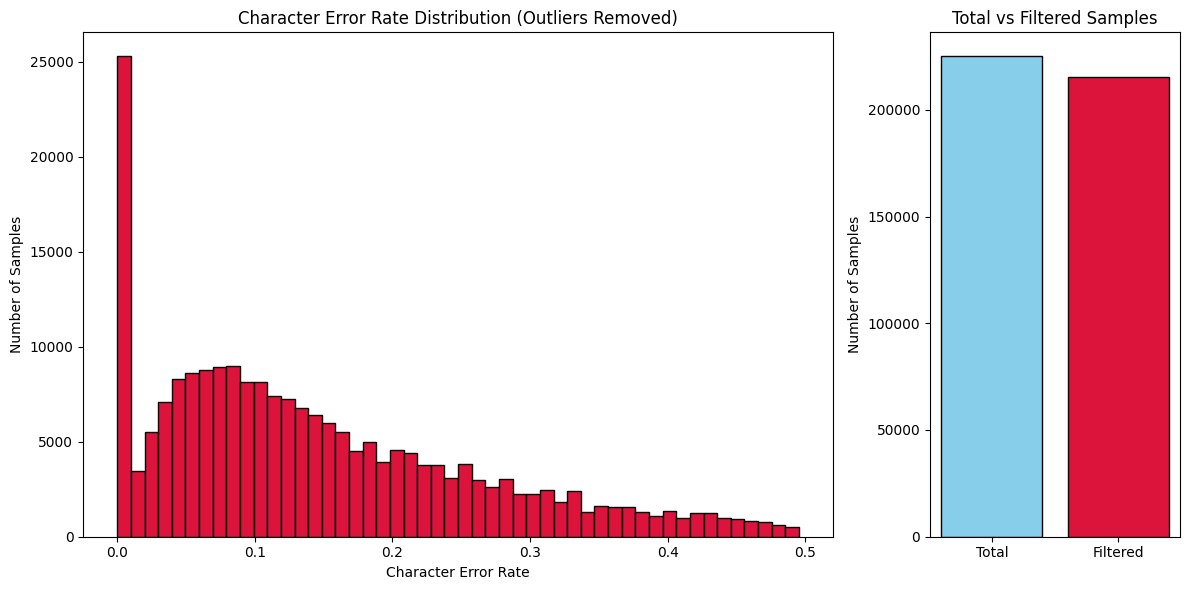

Outliers removed: 9618


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Compute Q1, Q3, and IQR
Q1 = np.percentile(cers, 25)
Q3 = np.percentile(cers, 75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
cers_filtered = [x for x in cers if lower_bound <= x <= upper_bound]

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1]})

# Left plot (75% width)
axes[0].hist(cers_filtered, bins=50, color='crimson', edgecolor='black')
axes[0].set_xlabel("Character Error Rate")
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("Character Error Rate Distribution (Outliers Removed)")

# Right plot (25% width)
axes[1].bar(["Total", "Filtered"], [len(cers), len(cers_filtered)], color=['skyblue', 'crimson'], edgecolor='black')
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Total vs Filtered Samples")

plt.tight_layout()
plt.show()

print(f"Outliers removed: {len(cers) - len(cers_filtered)}")

# CER Cumulative Distribution

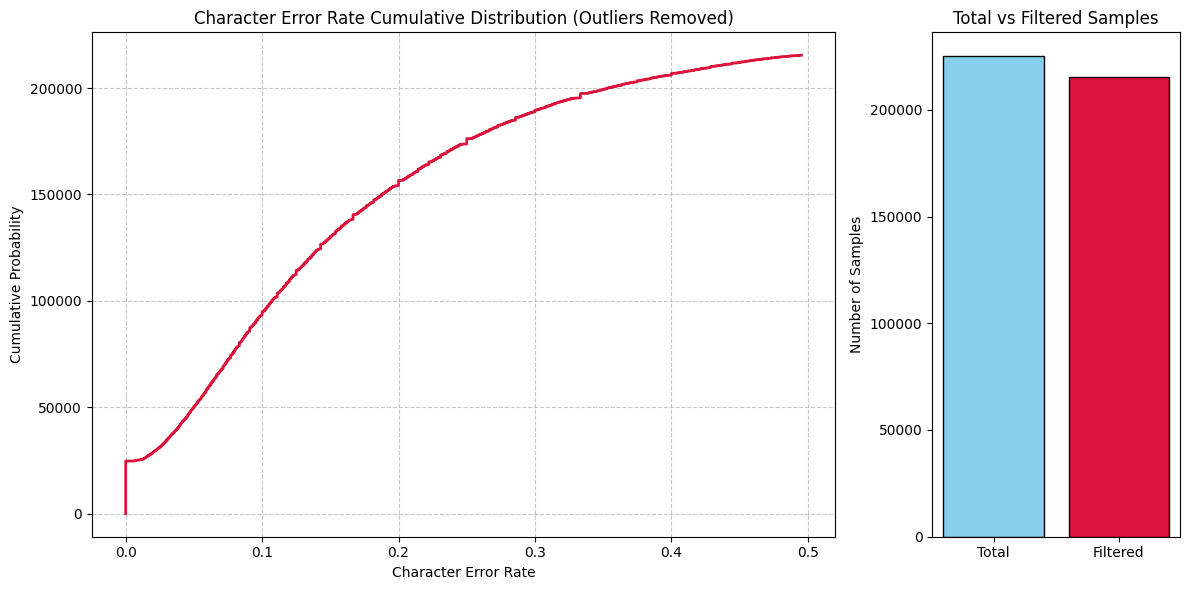

Outliers removed: 9618


In [18]:
# Compute Q1, Q3, and IQR
Q1 = np.percentile(cers, 25)
Q3 = np.percentile(cers, 75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
cers_filtered = [x for x in cers if lower_bound <= x <= upper_bound]

# Plot CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1]})

# Left plot (75% width) - now a CDF
# Sort the data for cumulative distribution
sorted_cers = np.sort(cers_filtered)
# Calculate the cumulative probabilities
yvals = np.arange(1, len(sorted_cers) + 1)

axes[0].plot(sorted_cers, yvals, 'crimson', linewidth=2)
axes[0].set_xlabel("Character Error Rate")
axes[0].set_ylabel("Cumulative Probability")
axes[0].set_title("Character Error Rate Cumulative Distribution (Outliers Removed)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right plot (25% width)
axes[1].bar(["Total", "Filtered"], [len(cers), len(cers_filtered)], color=['skyblue', 'crimson'], edgecolor='black')
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Total vs Filtered Samples")

plt.tight_layout()
plt.show()

print(f"Outliers removed: {len(cers) - len(cers_filtered)}")

In [19]:
# show sample at cer
sample_cer = 0.1
sample = df[df['cer'] == sample_cer]
sample = sample.sample(n=5)
for i, row in sample.iterrows():
    print(f"Filename: {row['filename']}")
    print(f"Original Text: {row['txt']}")
    print(f"Transcribed Text: {row['transcript']}")
    print(f"CER: {row['cer']}")
    print()

Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0561/thai-central_046501_mic1.flac
Original Text: สงสารไอเจ้าตัวเล็กขอให้เต้นเกิดในภพภูมิที่ดีนะครับ
Transcribed Text: สารไอ้เจ้าตัวเล็กขอให้เต้นเกิดในพบภูมิที่ดีนะครับ
CER: 0.1

Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0670/thai-central_122713_mic1.flac
Original Text: คุณสามีกำมะลอที่ฉายอยู่ตอนนี้ก็ดังค่ะสนุกกว่าดอกส้มสีทองด้วย
Transcribed Text: คุณสามีกรรมลอที่ใช้อยู่ตอนนี้ก็ดังค่ะสนุกกว่าดอกส้มสีทองด้วย
CER: 0.1

Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0589/thai-central_302285_mic1.flac
Original Text: ปลโปรดติดตามตอนต่อไป
Transcribed Text: รอโปรดติดตามตอนต่อไป
CER: 0.1

Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0963/thai-central_154826_mic1.flac
Original Text: และเมื่อฝนตกลงมาไม่สามารถดูดซับน้ำฝนได้จึงเกิดดินถล่มลงมาปิดทับเส้นทาง
Transcribed Text: และเมื่อฝนตกลงมาไม่สามารถตรวจสับน้ําฝนได้จึงเกิดดินถล่มลงมาปิดทับเส้นท